In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file_cleaned_path = "../data/cleaned/wine_data_cleaned.csv"

df_clean = pd.read_csv(file_cleaned_path)

print("=" * 50)
print("SHAPE (dataset dimension)")
print("=" * 50)
print(f"Number of lines : {df_clean.shape[0]}")
print(f"Number of columns : {df_clean.shape[1]}")
print(f"Dimensions : {df_clean.shape}")

print("\n" + "=" * 50)
print("COLUMNS (list of columns)")
print("=" * 50)
print(df_clean.columns.tolist())

print("\n" + "=" * 50)
print("INFO (data types and non-null values)")
print("=" * 50)
df_clean.info()

SHAPE (dataset dimension)
Number of lines : 54170
Number of columns : 12
Dimensions : (54170, 12)

COLUMNS (list of columns)
['id', 'country', 'description', 'designation', 'points', 'price', 'province', 'primary_region', 'taster_name', 'title', 'variety', 'winery']

INFO (data types and non-null values)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54170 entries, 0 to 54169
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              54170 non-null  int64  
 1   country         54170 non-null  object 
 2   description     54170 non-null  object 
 3   designation     54170 non-null  object 
 4   points          54170 non-null  int64  
 5   price           54170 non-null  float64
 6   province        54170 non-null  object 
 7   primary_region  54170 non-null  object 
 8   taster_name     54170 non-null  object 
 9   title           54170 non-null  object 
 10  variety         54170 non-null  object 


In [2]:
print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS - TEXT COLUMNS")
print("=" * 50)
print(df_clean[['country', 'designation', 'province', 'primary_region',
                'taster_name', 'variety', 'winery']].describe())

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS – NUMERICAL COLUMNS")
print("=" * 50)
print(df_clean[['price', 'points']].describe())
print("=" * 50 + "\n")


DESCRIPTIVE STATISTICS - TEXT COLUMNS
       country designation    province        primary_region taster_name  \
count    54170       54170       54170                 54170       54170   
unique       7       23943          63                  1004          17   
top         US     Reserve  California  Columbia Valley (WA)  Roger Voss   
freq     25888        1159       13998                  2488        9237   

           variety          winery  
count        54170           54170  
unique         434            8583  
top     Pinot Noir  Columbia Crest  
freq          6736             157  

DESCRIPTIVE STATISTICS – NUMERICAL COLUMNS
              price        points
count  54170.000000  54170.000000
mean      39.209341     88.966550
std       36.154076      2.955188
min        4.000000     80.000000
25%       20.000000     87.000000
50%       30.000000     89.000000
75%       48.000000     91.000000
max     2013.000000    100.000000



### Definition and Usage

- **count** - The number of not-empty values.
- **mean** - The average (mean) value.
- **std** - The standard deviation.
- **min** - The minimum value.
- **25%** - The 25% percentile*.
- **50%** - The 50% percentile*.
- **75%** - The 75% percentile*.
- **max** - The maximum value.

###### *Percentile meaning: how many of the values are less than the given percentile


In [3]:
print("Les pays producteurs de vin dans le dataset sont :", df_clean['country'].unique(), '\n')

print(df_clean['country'].value_counts())
print("\n" + "=" * 50)
print(df_clean['points'].value_counts())
print("\n" + "=" * 50)

Les pays producteurs de vin dans le dataset sont : ['US' 'Spain' 'Italy' 'France' 'Argentina' 'Australia' 'Canada'] 

country
US           25888
France       11597
Italy         7050
Spain         5194
Argentina     2818
Australia     1448
Canada         175
Name: count, dtype: int64

points
88     7300
90     6956
87     6201
91     5732
89     5635
92     4849
86     4303
93     3466
85     3018
94     1992
84     1852
83      955
95      738
82      490
96      231
81      183
80      136
97       80
98       34
99       12
100       7
Name: count, dtype: int64



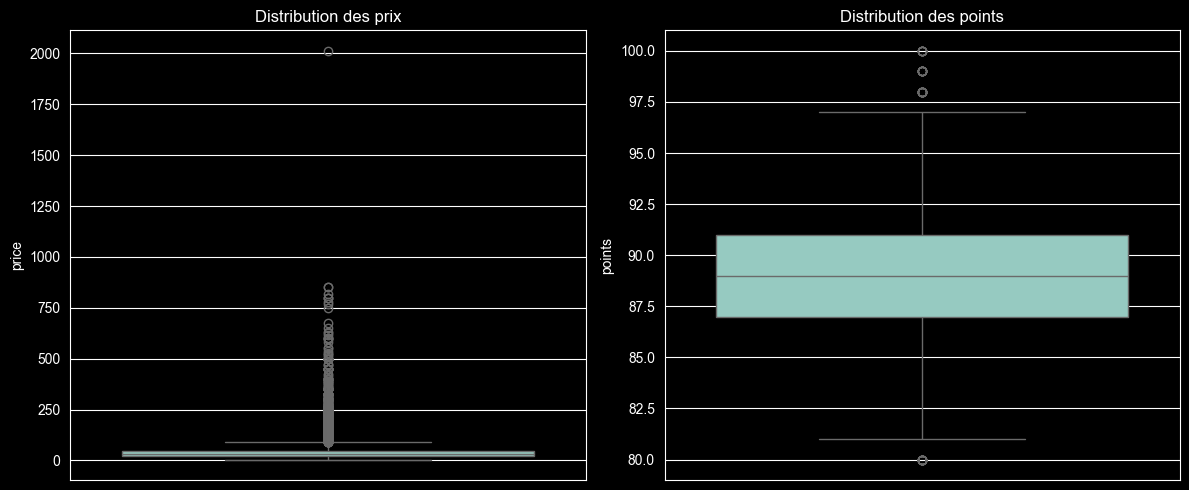

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_clean, y='price', ax=axes[0])
axes[0].set_title('Distribution des prix')
sns.boxplot(data=df_clean, y='points', ax=axes[1])
axes[1].set_title('Distribution des points')
plt.tight_layout()
plt.show()

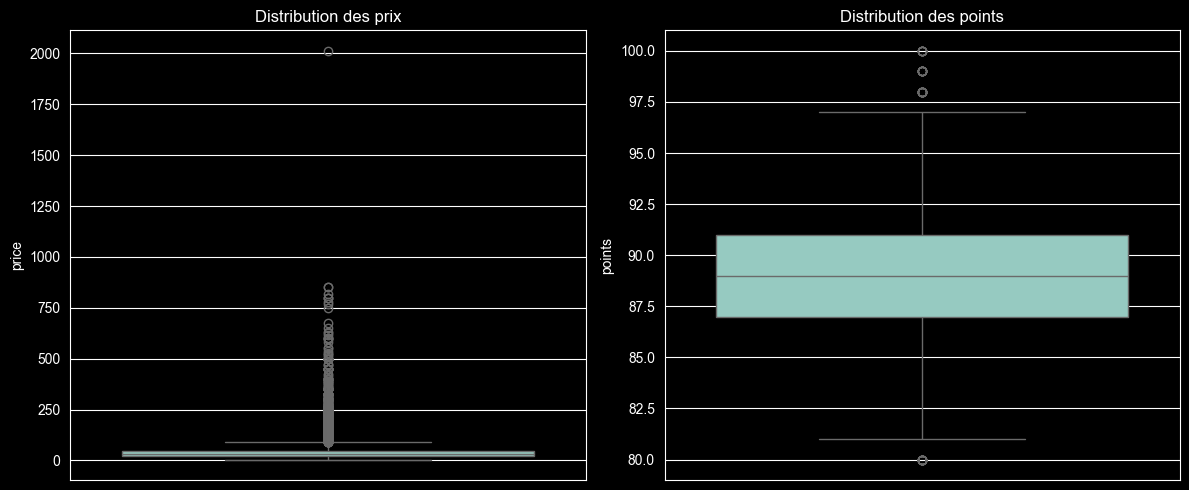

ANALYSE DES VALEURS ABERRANTES

PRICE:
Q1: 20.00
Q3: 48.00
IQR: 28.00
Bornes: [-22.00, 90.00]
Nombre d'outliers: 2666 (4.92%)
Prix min outlier: 91.00€
Prix max outlier: 2013.00€

POINTS:
Q1: 87.00
Q3: 91.00
IQR: 4.00
Bornes: [81.00, 97.00]
Nombre d'outliers: 189 (0.35%)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Créer les boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, y='price', ax=axes[0])
axes[0].set_title('Distribution des prix')

sns.boxplot(data=df_clean, y='points', ax=axes[1])
axes[1].set_title('Distribution des points')

plt.tight_layout()
plt.show()

# Analyser les outliers numériquement
print("=" * 60)
print("ANALYSE DES VALEURS ABERRANTES")
print("=" * 60)

# Pour price
Q1_price = df_clean['price'].quantile(0.25)
Q3_price = df_clean['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

outliers_price = df_clean[(df_clean['price'] < lower_bound_price) |
                          (df_clean['price'] > upper_bound_price)]

print(f"\nPRICE:")
print(f"Q1: {Q1_price:.2f}")
print(f"Q3: {Q3_price:.2f}")
print(f"IQR: {IQR_price:.2f}")
print(f"Bornes: [{lower_bound_price:.2f}, {upper_bound_price:.2f}]")
print(f"Nombre d'outliers: {len(outliers_price)} ({len(outliers_price)/len(df_clean)*100:.2f}%)")
print(f"Prix min outlier: {outliers_price['price'].min():.2f}€")
print(f"Prix max outlier: {outliers_price['price'].max():.2f}€")

# Pour points
Q1_points = df_clean['points'].quantile(0.25)
Q3_points = df_clean['points'].quantile(0.75)
IQR_points = Q3_points - Q1_points
lower_bound_points = Q1_points - 1.5 * IQR_points
upper_bound_points = Q3_points + 1.5 * IQR_points

outliers_points = df_clean[(df_clean['points'] < lower_bound_points) |
                           (df_clean['points'] > upper_bound_points)]

print(f"\nPOINTS:")
print(f"Q1: {Q1_points:.2f}")
print(f"Q3: {Q3_points:.2f}")
print(f"IQR: {IQR_points:.2f}")
print(f"Bornes: [{lower_bound_points:.2f}, {upper_bound_points:.2f}]")
print(f"Nombre d'outliers: {len(outliers_points)} ({len(outliers_points)/len(df_clean)*100:.2f}%)")

In [6]:
# Ces vins sont des OUTLIERS STATISTIQUES mais PAS des ERREURS
print("Exemples de vins > 90€ (outliers selon IQR) :")
expensive_wines = df_clean[df_clean['price'] > 90].sort_values('price', ascending=False)
print(expensive_wines[['country', 'variety', 'price', 'points']].head(10))

Exemples de vins > 90€ (outliers selon IQR) :
         country     variety   price  points
50165         US  Chardonnay  2013.0      91
31901  Australia      Shiraz   850.0      98
23586  Australia      Shiraz   850.0      99
23591  Australia      Shiraz   820.0      96
15027     France  Chardonnay   800.0      99
45131      Italy  Sangiovese   800.0      94
40422     France        Rosé   800.0      87
16424  Australia      Shiraz   780.0      91
6560       Spain    Carignan   770.0      96
21524         US       Syrah   750.0      92
